In [17]:
import anndata as ad
import pandas as pd
import numpy as np
from pathlib import Path
import os
import socket
import scanpy as sc
from itertools import islice
import json

print(f"Running on node: {socket.gethostname()}")
print(os.getcwd())
print(os.path.expanduser("~"))

Running on node: n-62-20-1
/zhome/bf/7/219671/projects/DL_project
/zhome/bf/7/219671


In [ ]:
class NumpyEncoder(json.JSONEncoder):
    """ json encoder for numpy types """
    def default(self, obj):
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        if isinstance(obj, (np.int64, np.int32, np.int8)):
            return int(obj)
        if isinstance(obj, (np.float64, np.float32)):
            return float(obj)
        return json.JSONEncoder.default(self, obj)

In [4]:
source_path = Path("/work3/s252608/DL_project/data/raw")

raw_data = ['bulk_processed_genes.h5ad',
            'bulk_processed_transcripts.h5ad',
            'sc_processed_genes.h5ad',
            'sc_processed_transcripts.h5ad']

In [7]:
for raw in raw_data:
    adata = ad.read_h5ad(f'{source_path}/{raw}', backed='r')
    print(f'\n{raw} loaded')
    print(f'Size: {adata.shape}')
    print(f'Matrix type: {type(adata.X)}')
    print(f'Samples: {adata.n_obs}')
    print(f'Sample names: {adata.obs_names[:10]}')
    print(f'Variables: {adata.n_vars}')     # genes or transcripts
    print(f'Variable IDs: {adata.var_names[:10]}') 
    if hasattr(adata, 'uns') and adata.uns:
        print(f'Unstructured metadata: {list(adata.uns.keys())}')
    else:
        print('No unstructured metadata')
    if hasattr(adata, 'layers') and adata.layers:
        print(f'Layers: {list(adata.layers.keys())}')
    else:
        print('No layers')


bulk_processed_genes.h5ad loaded
Size: (19882, 45263)
Matrix type: <class 'anndata._core.sparse_dataset._CSRDataset'>
Samples: 19882
Sample names: Index(['GSM1019741', 'GSM1020212', 'GSM1041196', 'GSM1060226', 'GSM1060355',
       'GSM1062239', 'GSM1070765', 'GSM1071857', 'GSM1081537', 'GSM1085740'],
      dtype='object')
Variables: 45263
Variable IDs: Index(['DDX11L1', 'WASH7P', 'FAM138A', 'OR4F5', 'ENSG00000238009',
       'ENSG00000239945', 'CICP27', 'ENSG00000268903', 'ENSG00000269981',
       'ENSG00000239906'],
      dtype='object')
Unstructured metadata: ['gene_n_transcripts', 'gene_to_transcripts', 'instrument_model_colors', 'leiden', 'leiden_colors', 'log1p', 'multi_isoform_genes', 'single_isoform_genes', 'transcript_id_to_index', 'transcript_ids', 'transcript_mapping']
No layers

bulk_processed_transcripts.h5ad loaded
Size: (19882, 162009)
Matrix type: <class 'anndata._core.sparse_dataset._CSRDataset'>
Samples: 19882
Sample names: Index(['GSM1019741', 'GSM1020212', 'GSM10411

In [5]:
exp_data = ad.read_h5ad(f'{source_path}/bulk_processed_genes.h5ad', backed='r')

In [4]:
print(exp_data.obs.columns)

if 'series_id' in exp_data.obs:
    print(exp_data.obs['series_id'].value_counts())

Index(['geo_accession', 'series_id', 'characteristics_ch1',
       'extract_protocol_ch1', 'source_name_ch1', 'title', 'contact_city',
       'contact_country', 'contact_institute', 'instrument_model',
       'library_source', 'organism_ch1', 'platform_id',
       'singlecellprobability', 'submission_date', 'taxid_ch1',
       'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes',
       'pct_counts_in_top_500_genes', 'total_counts_mt', 'pct_counts_mt',
       'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb',
       'pct_counts_hb', 'mt_outlier', 'n_counts', 'n_genes', 'leiden'],
      dtype='object')
series_id
GSE40705             1
GSE41586,GSE41588    1
GSE41616             1
GSE42509,GSE45833    1
GSE43296             1
                    ..
GSE44976             1
GSE45157             1
GSE45258             1
GSE45263             1
GSE45326             1
Name: count, Length: 19882, dtype: int

In [19]:
iso_dict = exp_data.uns['gene_to_transcripts']
first_10 = dict(islice(iso_dict.items(), 10))
print(first_10)

with open("/work3/s252608/DL_project/data/gene_to_transcripts.json", "w") as f:
    json.dump(iso_dict, f, cls=NumpyEncoder, indent=4)

{'A1BG': array(['ENST00000596924', 'ENST00000595014', 'ENST00000598345',
       'ENST00000600966'], dtype=object), 'A1BG-AS1': array(['ENST00000670460', 'ENST00000593960', 'ENST00000594950',
       'ENST00000593374', 'ENST00000599728', 'ENST00000600379',
       'ENST00000595302', 'ENST00000670199'], dtype=object), 'A1CF': array(['ENST00000395489', 'ENST00000282641', 'ENST00000373993',
       'ENST00000373995', 'ENST00000493415', 'ENST00000473480',
       'ENST00000414883'], dtype=object), 'A2M': array(['ENST00000543436', 'ENST00000545828', 'ENST00000542567',
       'ENST00000472360', 'ENST00000539638', 'ENST00000404455',
       'ENST00000467091', 'ENST00000497324'], dtype=object), 'A2M-AS1': array(['ENST00000667950', 'ENST00000670582', 'ENST00000499762'],
      dtype=object), 'A2ML1': array(['ENST00000536789', 'ENST00000539547', 'ENST00000540049',
       'ENST00000537475'], dtype=object), 'A2ML1-AS1': array(['ENST00000537288'], dtype=object), 'A2ML1-AS2': array(['ENST00000394240'], dty

Unique Instruments: 13
Unique Platforms: 13


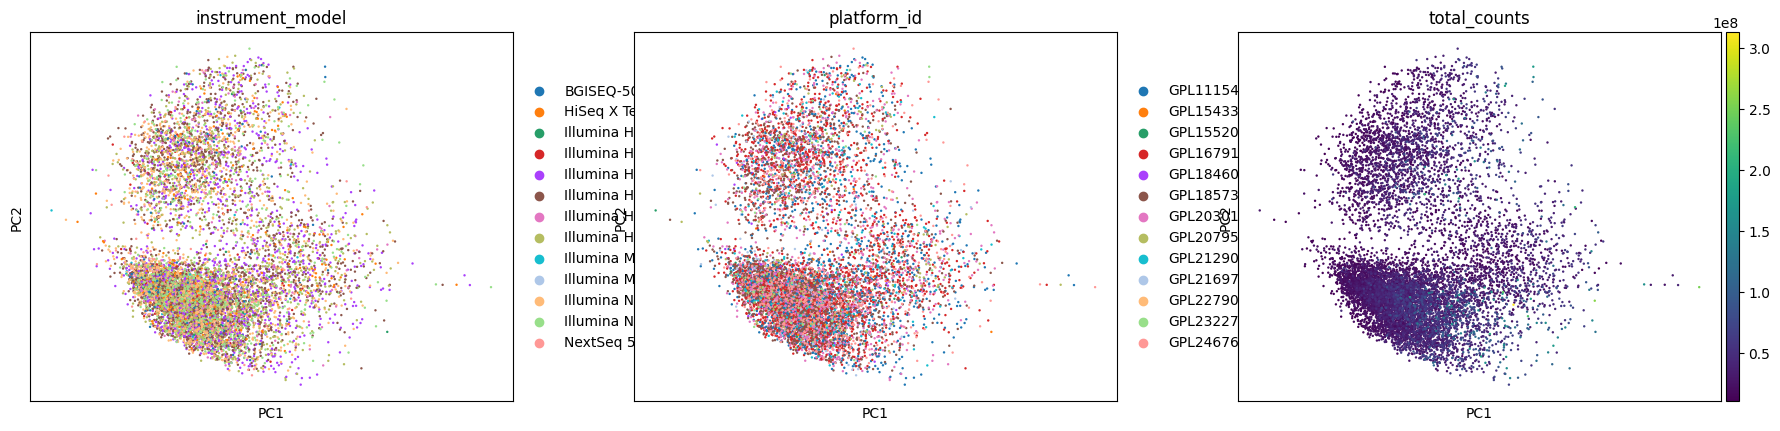

In [7]:
print("Unique Instruments:", exp_data.obs['instrument_model'].nunique())
print("Unique Platforms:", exp_data.obs['platform_id'].nunique())

sub_adata = exp_data[:10000, :].to_memory() 
sc.pp.log1p(sub_adata)
sc.pp.highly_variable_genes(sub_adata, n_top_genes=5000)
sc.pp.pca(sub_adata)

sc.pl.pca(sub_adata, color=['instrument_model', 'platform_id', 'total_counts'])